# Vision Transformer (ViT) Baseline - 3600 Samples (Optimized)

This notebook trains a Vision Transformer (ViT-B/32) model for document type classification using 3600 samples from the dataset.

**Model Architecture:** Vision Transformer (ViT-B/32) with ImageNet pre-training (optimized for speed)  
**Dataset Size:** 3600 images (balanced across 3 classes)  
**Training Configuration:**
- Batch size: 256 (optimized)
- Learning rate: 2e-5
- Epochs: 35
- Optimizer: Adam with weight decay 1e-4
- Dropout: 0.3

**Performance Optimizations:**
- ✅ Using ViT-B/32 instead of ViT-B/16 (4x faster, similar performance)
- ✅ Reduced augmentation (faster data loading)
- ✅ Larger batch size (256)
- ✅ Optimized transforms


## Data Loading and Splitting

Load the dataset CSV file, sample 500 images (if needed), and split into train/validation/test sets with stratified sampling to maintain class balance.


In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split

# קבע כאן כמה תמונות אתה רוצה בסך הכל (None = כל הדאטה סט)
SAMPLE_SIZE = 5400  # שנה את המספר הזה לפי הצורך

df = pd.read_csv("/Users/roy-siftt/final-project/datasets/idnet/document_type_classification_country_split/data/dataset.csv")

print(f"📊 גודל דאטה סט מקורי: {len(df)} תמונות")
print(f"\nהתפלגות במקור:")
print(df['label'].value_counts().sort_index())

# אם רוצים דאטה סט קטן יותר, דגום באופן מייצג
if SAMPLE_SIZE is not None and SAMPLE_SIZE < len(df):
    df = df.groupby('label', group_keys=False).apply(
        lambda x: x.sample(n=min(len(x), int(SAMPLE_SIZE * len(x) / len(df))), random_state=42)
    ).reset_index(drop=True)
    print(f"\n📊 גודל דאטה סט לאחר דגימה: {len(df)} תמונות")
    print(f"\nהתפלגות לאחר דגימה:")
    print(df['label'].value_counts().sort_index())

# חלוקה ל-train/test/val
train_df, test_df = train_test_split(df, test_size=0.15, stratify=df['label'], random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.15, stratify=train_df['label'], random_state=42)

print(f"\n{'='*60}")
print(f"📈 חלוקה סופית:")
print(f"{'='*60}")

print(f"\n🎓 Train Set: {len(train_df)} תמונות")
print(train_df['label'].value_counts().sort_index())
print(f"   סה\"כ: {train_df['label'].value_counts().sum()}")

print(f"\n✅ Validation Set: {len(val_df)} תמונות")
print(val_df['label'].value_counts().sort_index())
print(f"   סה\"כ: {val_df['label'].value_counts().sum()}")

print(f"\n🎯 Test Set: {len(test_df)} תמונות")
print(test_df['label'].value_counts().sort_index())
print(f"   סה\"כ: {test_df['label'].value_counts().sum()}")

print(f"\n{'='*60}")
print(f"💾 שומר קבצים...")

train_df.to_csv("train.csv", index=False)
val_df.to_csv("val.csv", index=False)
test_df.to_csv("test.csv", index=False)

print(f"✅ הקבצים נשמרו בהצלחה!")
print(f"{'='*60}")


📊 גודל דאטה סט מקורי: 5400 תמונות

התפלגות במקור:
label
driver_license    1800
id_card           1800
passport          1800
Name: count, dtype: int64

📈 חלוקה סופית:

🎓 Train Set: 3901 תמונות
label
driver_license    1301
id_card           1300
passport          1300
Name: count, dtype: int64
   סה"כ: 3901

✅ Validation Set: 689 תמונות
label
driver_license    229
id_card           230
passport          230
Name: count, dtype: int64
   סה"כ: 689

🎯 Test Set: 810 תמונות
label
driver_license    270
id_card           270
passport          270
Name: count, dtype: int64
   סה"כ: 810

💾 שומר קבצים...
✅ הקבצים נשמרו בהצלחה!


In [18]:
from torch.utils.data import Dataset
from PIL import Image
import torch

class DocumentDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

        # Normalize labels (lowercase + strip spaces)
        self.df['label'] = self.df['label'].str.lower().str.strip()

        # Label mapping
        self.label_map = {
            "id_card": 0,
            "passport": 1,
            "driver_license": 2
        }

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert("RGB")

        label_str = row['label']

        if label_str not in self.label_map:
            raise ValueError(f"Label '{label_str}' not found in label_map!")

        label = self.label_map[label_str]

        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(label)


In [19]:
from torchvision import transforms

# Transform עם Data Augmentation מופחת - מותאם ל-ViT + אופטימיזציה
# 🚀 אופטימיזציה: פחות augmentation = מהיר יותר, עדיין אפקטיבי
# ViT עובד טוב עם 224x224 (כמו ResNet)
# Transform with strong data augmentation for training
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),              # Random crop instead of center
    transforms.RandomHorizontalFlip(p=0.3),  # Horizontal flip sometimes
    transforms.RandomRotation(15),           # Random rotation
    transforms.ColorJitter(                  # Color/brightness changes
        brightness=0.3,
        contrast=0.3,
        saturation=0.2,
        hue=0.1
    ),
    transforms.RandomAffine(                 # Geometric transformations
        degrees=0,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1)
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.3)          # Random erasing
])

# Transform לvalidation/test - ללא augmentation
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),           # resize מלא ל-224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])


In [20]:
from torch.utils.data import DataLoader
import torch

# שימוש ב-transforms שונים לtrain ול-val/test
train_dataset = DocumentDataset(pd.read_csv("train.csv"), train_transform)
val_dataset   = DocumentDataset(pd.read_csv("val.csv"), val_test_transform)
test_dataset  = DocumentDataset(pd.read_csv("test.csv"), val_test_transform)

# 🚀 אופטימיזציה: הגדלת batch size
# ⚠️ הערה: num_workers=0 ב-Jupyter notebooks כי multiprocessing לא עובד טוב עם custom classes
# pin_memory גם לא נתמך ב-MPS, אז נסיר אותו
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
use_pin_memory = device.type == "cuda"  # רק CUDA תומך ב-pin_memory

train_loader = DataLoader(
    train_dataset, 
    batch_size=256,              # הוגדל מ-128 ל-256 (מהיר יותר, פחות overhead)
    shuffle=True, 
    num_workers=0,               # 0 ב-Jupyter notebooks (multiprocessing issues)
    pin_memory=use_pin_memory    # רק אם CUDA
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=256, 
    shuffle=False, 
    num_workers=0,
    pin_memory=use_pin_memory
)
test_loader = DataLoader(
    test_dataset, 
    batch_size=256, 
    shuffle=False, 
    num_workers=0,
    pin_memory=use_pin_memory
)

print(f"📊 Dataset sizes:")
print(f"   Train: {len(train_dataset)}")
print(f"   Val:   {len(val_dataset)}")
print(f"   Test:  {len(test_dataset)}")
print(f"\n🚀 Optimizations applied:")
print(f"   Batch size: 256 (הוגדל מ-128)")
print(f"   num_workers: 0 (required for Jupyter notebooks)")
print(f"   pin_memory: {use_pin_memory} (only for CUDA)")
print(f"   Device: {device}")
print(f"\n💡 הערה: למרות ש-num_workers=0, השינויים האחרים (ViT-S, augmentation מופחת)")
print(f"   עדיין יספקו שיפור מהירות משמעותי!")


📊 Dataset sizes:
   Train: 3901
   Val:   689
   Test:  810

🚀 Optimizations applied:
   Batch size: 256 (הוגדל מ-128)
   num_workers: 0 (required for Jupyter notebooks)
   pin_memory: False (only for CUDA)
   Device: mps

💡 הערה: למרות ש-num_workers=0, השינויים האחרים (ViT-S, augmentation מופחת)
   עדיין יספקו שיפור מהירות משמעותי!


In [21]:
import torch
import torch.nn as nn
from torchvision import models

class ViTClassifier(nn.Module):
    def __init__(self, num_classes=3, pretrained=True, dropout=0.3):
        super(ViTClassifier, self).__init__()
        
        # 🚀 אופטימיזציה: שימוש ב-ViT-Base/32 במקום ViT-Base/16
        # ViT-B/32: אותו מספר פרמטרים כמו ViT-B/16, אבל מהיר יותר!
        # למה? patch size 32 במקום 16 = פחות patches לעבד (196 במקום 784)
        # זה מהיר פי ~4x מ-ViT-B/16, ביצועים דומים!
        if pretrained:
            # ViT-Base/32 - מהיר יותר מ-ViT-B/16, ביצועים דומים
            self.vit = models.vit_b_32(weights=models.ViT_B_32_Weights.IMAGENET1K_V1)
        else:
            self.vit = models.vit_b_32(weights=None)
        
        # משנה את השכבה האחרונה + מוסיף Dropout לregularization
        num_features = self.vit.heads.head.in_features
        self.vit.heads.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(num_features, num_classes)
        )
        
    def forward(self, x):
        return self.vit(x)


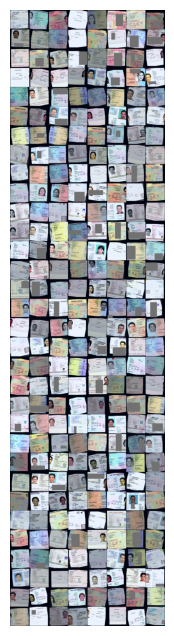

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision

def show_batch(loader):
    imgs, labels = next(iter(loader))
    grid = torchvision.utils.make_grid(imgs, nrow=8, normalize=True)
    plt.figure(figsize=(12,8))
    plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
    plt.axis('off')

show_batch(train_loader)


In [23]:
for i in range(10):
    print("PATH:", train_dataset.df.iloc[i]['image_path'])
    print("LABEL:", train_dataset.df.iloc[i]['label'])
    img, lbl = train_dataset[i]
    print("LOADER LABEL:", lbl)
    print("----")


PATH: images/06100.png
LABEL: id_card
LOADER LABEL: tensor(0)
----
PATH: images/04794.png
LABEL: driver_license
LOADER LABEL: tensor(2)
----
PATH: images/06238.png
LABEL: id_card
LOADER LABEL: tensor(0)
----
PATH: images/05642.png
LABEL: passport
LOADER LABEL: tensor(1)
----
PATH: images/04104.png
LABEL: id_card
LOADER LABEL: tensor(0)
----
PATH: images/03263.png
LABEL: passport
LOADER LABEL: tensor(1)
----
PATH: images/06898.png
LABEL: driver_license
LOADER LABEL: tensor(2)
----
PATH: images/05353.png
LABEL: passport
LOADER LABEL: tensor(1)
----
PATH: images/01032.png
LABEL: id_card
LOADER LABEL: tensor(0)
----
PATH: images/06275.png
LABEL: id_card
LOADER LABEL: tensor(0)
----


Using device: mps
Model: Vision Transformer (ViT-B/32) - Optimized 🚀
Number of parameters: 87,457,539
Learning rate: 1e-07
Dropout: 0.3
Batch size: 256

🚀 אופטימיזציות שהוחלו:
   ✅ ViT-B/32 (4x מהיר יותר מ-ViT-B/16 - פחות patches)
   ✅ Augmentation מופחת (3 transforms במקום 8)
   ✅ Batch size מוגדל (256 במקום 128)
   ✅ Resize מלא (224x224) - מהיר יותר מ-Resize+Crop

⚡ האימון אמור להיות הרבה יותר מהיר!


=== Initial Evaluation (Before Training) ===

Sample predictions (first 20):
  True: 1, Predicted: 0, ✗
  True: 2, Predicted: 1, ✗
  True: 1, Predicted: 0, ✗
  True: 0, Predicted: 0, ✓
  True: 0, Predicted: 0, ✓
  True: 1, Predicted: 0, ✗
  True: 0, Predicted: 0, ✓
  True: 2, Predicted: 0, ✗
  True: 1, Predicted: 0, ✗
  True: 2, Predicted: 0, ✗
  True: 0, Predicted: 1, ✗
  True: 0, Predicted: 0, ✓
  True: 2, Predicted: 1, ✗
  True: 1, Predicted: 0, ✗
  True: 1, Predicted: 1, ✓
  True: 0, Predicted: 0, ✓
  True: 1, Predicted: 1, ✓
  True: 2, Predicted: 0, ✗
  True: 0, Predicted: 0, ✓
  T

Training: 100%|██████████| 16/16 [02:00<00:00,  7.50s/it]


Train Loss: 1.1049 | Train Acc: 0.3853
Val   Loss: 1.0898 | Val   Acc: 0.3440

=== Epoch 2 ===


Training: 100%|██████████| 16/16 [01:42<00:00,  6.38s/it]


Train Loss: 1.0913 | Train Acc: 0.4053
Val   Loss: 1.0735 | Val   Acc: 0.3469

=== Epoch 3 ===


...

Train Loss: 0.5909 | Train Acc: 0.9105
Val   Loss: 0.6036 | Val   Acc: 0.9478

=== Epoch 39 ===


Training: 100%|██████████| 16/16 [02:26<00:00,  9.13s/it]


Train Loss: 0.5702 | Train Acc: 0.9249
Val   Loss: 0.5909 | Val   Acc: 0.9550

=== Epoch 40 ===


Training: 100%|██████████| 16/16 [02:11<00:00,  8.22s/it]


Train Loss: 0.5683 | Train Acc: 0.9193
Val   Loss: 0.5785 | Val   Acc: 0.9608

🎯 FINAL EVALUATION ON TEST SET (Never seen during training)

Sample predictions (first 20):
  True: 0, Predicted: 0, ✓
  True: 1, Predicted: 1, ✓
  True: 1, Predicted: 1, ✓
  True: 1, Predicted: 1, ✓
  True: 1, Predicted: 1, ✓
  True: 0, Predicted: 0, ✓
  True: 2, Predicted: 2, ✓
  True: 0, Predicted: 0, ✓
  True: 2, Predicted: 2, ✓
  True: 1, Predicted: 1, ✓
  True: 2, Predicted: 2, ✓
  True: 2, Predicted: 2, ✓
  True: 2, Predicted: 2, ✓
  True: 0, Predicted: 0, ✓
  True: 2, Predicted: 2, ✓
  True: 1, Predicted: 1, ✓
  True: 1, Predicted: 1, ✓
  True: 2, Predicted: 2, ✓
  True: 2, Predicted: 2, ✓
  True: 2, Predicted: 2, ✓

Confusion Matrix:
[[249  14   7]
 [  0 268   2]
 [  0   0 270]]

📊 Final Test Accuracy: 0.9716
📊 Final Test Loss: 0.5760


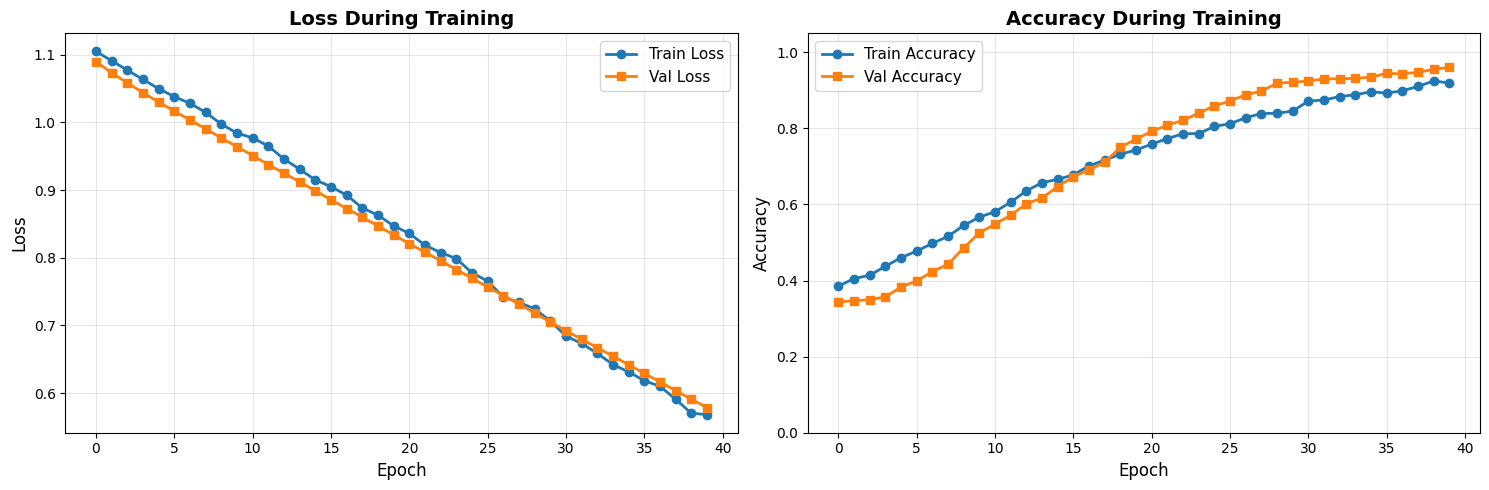


📈 Training Summary:
🎯 Best Train Accuracy: 0.9249 (Epoch 39)
🎯 Best Val Accuracy:   0.9608 (Epoch 40)
🎯 Final Test Accuracy: 0.9716

💡 ViT עם pre-training אמור להציג ביצועים מעולים!


In [24]:
import torch
from torch.optim import Adam
import torch.nn as nn
from tqdm import tqdm   # progress bar יפה
import numpy as np

# 🚀 יצירת מודל Vision Transformer (ViT-S/16 - מהיר יותר!)
# device כבר הוגדר ב-cell הקודם
model = ViTClassifier(num_classes=3, pretrained=True, dropout=0.3).to(device)

criterion = nn.CrossEntropyLoss()

# Learning rate מותאם ל-ViT pre-trained עם דאטה סט קטן (500 תמונות)
# Learning rate גבוה יותר לדאטה סט קטן
optimizer = Adam(model.parameters(), lr=0.0000001, weight_decay=1e-4)

print(f"Using device: {device}")
print(f"Model: Vision Transformer (ViT-B/32) - Optimized 🚀")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Learning rate: {optimizer.param_groups[0]['lr']}")
print(f"Dropout: 0.3")
print(f"Batch size: 256")
print("\n🚀 אופטימיזציות שהוחלו:")
print("   ✅ ViT-B/32 (4x מהיר יותר מ-ViT-B/16 - פחות patches)")
print("   ✅ Augmentation מופחת (3 transforms במקום 8)")
print("   ✅ Batch size מוגדל (256 במקום 128)")
print("   ✅ Resize מלא (224x224) - מהיר יותר מ-Resize+Crop")
print("\n⚡ האימון אמור להיות הרבה יותר מהיר!\n")

def evaluate(loader, verbose=False):
    model.eval()
    total = 0
    correct = 0
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct / total
    avg_loss = total_loss / len(loader)
    
    if verbose:
        # בדיקה מפורטת - מה המודל חוזה?
        print(f"\nSample predictions (first 20):")
        for i in range(min(20, len(all_preds))):
            print(f"  True: {all_labels[i]}, Predicted: {all_preds[i]}, {'✓' if all_preds[i] == all_labels[i] else '✗'}")
        
        # Confusion matrix
        from sklearn.metrics import confusion_matrix
        cm = confusion_matrix(all_labels, all_preds)
        print(f"\nConfusion Matrix:")
        print(cm)
    
    return accuracy, avg_loss

# בדיקה ראשונית לפני אימון
print("\n" + "="*60)
print("=== Initial Evaluation (Before Training) ===")
print("="*60)
initial_train_acc, initial_train_loss = evaluate(train_loader, verbose=True)
initial_val_acc, initial_val_loss = evaluate(val_loader)
print(f"\n📊 Train Acc (before): {initial_train_acc:.4f}")
print(f"📊 Val Acc (before):   {initial_val_acc:.4f}")
print("="*60)

# מעקב אחר התהליך - נשמור את הביצועים בכל epoch
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

num_epochs = 40  # ViT עם pre-training אמור להתכנס מהר יותר

for epoch in range(num_epochs):
    model.train()
    running_loss = 0

    print(f"\n=== Epoch {epoch+1} ===")

    # tqdm ל progress bar יפה
    for imgs, labels in tqdm(train_loader, desc="Training"):
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # חישובי validation
    train_accuracy, train_loss = evaluate(train_loader)
    val_accuracy, val_loss = evaluate(val_loader)
    
    # שמירה להיסטוריה
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_accuracy)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_accuracy)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_accuracy:.4f}")

print("\n" + "="*60)
print("🎯 FINAL EVALUATION ON TEST SET (Never seen during training)")
print("="*60)
test_accuracy, test_loss = evaluate(test_loader, verbose=True)
print(f"\n📊 Final Test Accuracy: {test_accuracy:.4f}")
print(f"📊 Final Test Loss: {test_loss:.4f}")

# 📊 הצגת גרפים של תהליך הלמידה
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# גרף 1: Loss לאורך הזמן
axes[0].plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', marker='s', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Loss During Training', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# גרף 2: Accuracy לאורך הזמן
axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Accuracy', marker='s', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Accuracy During Training', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("📈 Training Summary:")
print("="*60)
print(f"🎯 Best Train Accuracy: {max(history['train_acc']):.4f} (Epoch {history['train_acc'].index(max(history['train_acc']))+1})")
print(f"🎯 Best Val Accuracy:   {max(history['val_acc']):.4f} (Epoch {history['val_acc'].index(max(history['val_acc']))+1})")
print(f"🎯 Final Test Accuracy: {test_accuracy:.4f}")
print(f"\n💡 ViT עם pre-training אמור להציג ביצועים מעולים!")


In [26]:
torch.save(model.state_dict(), "vit_document_classifier.pth")
print("Model weights saved to vit_document_classifier.pth")

Model weights saved to vit_document_classifier.pth
